In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## EX 7

In [5]:
data = pd.read_json("./neowise.json")
data.head(10)

,designation,discovery_date,h_mag,moid_au,q_au_1,q_au_2,period_yr,i_deg,pha,orbit_class
0,419880 (2011 AH37),2011-01-07T00:00:00.000,19.7,0.035,0.84,4.26,4.06,9.65,Y,Apollo
1,419624 (2010 SO16),2010-09-17T00:00:00.000,20.5,0.028,0.93,1.08,1.00,14.52,Y,Apollo
2,414772 (2010 OC103),2010-07-28T00:00:00.000,19.0,0.333,0.39,2.00,1.31,23.11,N,Apollo
3,414746 (2010 EH20),2010-03-06T00:00:00.000,18.0,0.268,1.25,3.99,4.24,23.89,N,Amor
4,407324 (2010 OB101),2010-07-18T00:00:00.000,20.7,0.111,0.77,2.46,2.06,9.12,N,Apollo
5,398188 (2010 LE15),2010-06-03T00:00:00.000,19.5,0.024,0.63,1.10,0.80,13.25,Y,Aten
6,395207 (2010 HQ80),2010-04-25T00:00:00.000,19.6,0.007,0.80,2.34,1.96,27.85,Y,Apollo
7,386847 (2010 LR33),2010-06-06T00:00:00.000,18.0,0.029,0.91,2.48,2.20,5.84,Y,Apollo
8,381989 (2010 HR80),2010-04-28T00:00:00.000,19.9,0.104,0.68,2.02,1.56,26.71,N,Apollo
9,369454 (2010 NZ1),2010-07-09T00:00:00.000,19.4,0.275,0.49,2.26,1.61,32.78,N,Apollo


In [16]:
#Query per la media del periodo orbitale
data.groupby('orbit_class')['period_yr'].mean()

orbit_class
Amor                          5.235082
Apollo                        2.941143
Aten                          0.891333
Comet                    238220.625556
Encke-type Comet              5.490000
Halley-type Comet*           23.375000
Jupiter-family Comet          8.380000
Jupiter-family Comet*        17.300000
Parabolic Comet                    NaN
Name: period_yr, dtype: float64

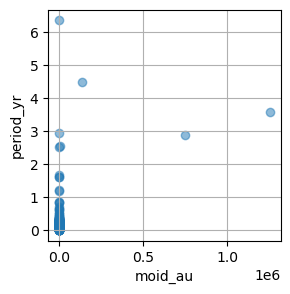

In [23]:
#moid_au e period_yr

moid_au = data['moid_au'].to_numpy()
period_yr = data['period_yr'].to_numpy()

fig, ax = plt.subplots(figsize=(3,3))
ax.scatter(period_yr, moid_au, alpha=0.5)
ax.set_xlabel("moid_au")
ax.set_ylabel("period_yr")
ax.grid()
plt.show()

## EX 8

In [24]:
#per ogni isola, quanti pinguini di ogni specie
#sono stati avvistati

#value_counts()

In [25]:
data_pinguini = pd.read_csv('./penguins_size.csv')
data_pinguini.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [27]:
data_pinguini.groupby('island')['species'].value_counts()

island     species  
Biscoe     Gentoo       124
           Adelie        44
Dream      Chinstrap     68
           Adelie        56
Torgersen  Adelie        52
Name: count, dtype: int64

## EX 9

In [28]:
data = pd.read_csv('./penguins_size.csv')
data.head(10)

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE
6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,FEMALE
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,MALE
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN


In [46]:
#numero di pinguini femmina tra quelli che hanno
#il peso minore di 3,7 kg
data[(data.body_mass_g < 3700) & (data['sex'] == 'FEMALE')]['sex'].count()

np.int64(85)

In [49]:
#numero di pinguini femmina tra quelli che hanno peso minore di 3,7 kg
#e sono di specie Gentoo
data[(data.body_mass_g < 3700) & (data['sex'] == 'FEMALE') &
    (data['species'] == 'Gentoo')]['species'].count()

np.int64(0)

In [55]:
#La lunghezza media in millimetri della pinna (colonna flipper length)
#tra i pinguini adelie
data[data['species'] == 'Adelie']['flipper_length_mm'].mean()

np.float64(189.95364238410596)

In [57]:
#La lunghezza media in millimetri della pinna tra i pinguini adelie maschi
data[(data['species'] == 'Adelie') & 
    (data['sex'] == 'MALE')]['flipper_length_mm'].mean()

np.float64(192.41095890410958)

In [61]:
#il peso del pinguini maschio adelie più piccolo
data[(data['species'] == 'Adelie') & (data['sex'] == 'MALE')]['body_mass_g'].min()

3325.0

## EX 10

In [91]:
data = pd.read_csv('./marziani.csv')
data['colore'].value_counts()

colore
blu      674
rosso    662
viola    657
Name: count, dtype: int64

In [108]:
data['colore'].unique()
data['specie'].unique()

array(['Robby', 'Simmy'], dtype=object)

In [98]:
#Fare l'analisi grafica completa, prima devo ri-convertire 
dati_puliti = data.dropna().copy()
dati_puliti.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1979 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   specie     1979 non-null   object 
 1   colore     1979 non-null   object 
 2   n_arti     1979 non-null   float64
 3   peso       1979 non-null   float64
 4   altezza    1979 non-null   float64
 5   larghezza  1979 non-null   float64
dtypes: float64(4), object(2)
memory usage: 108.2+ KB


In [101]:
colori_dict = {'viola': 0, 'rosso': 1, 'blu': 2}
arrayColori = np.array([colori_dict[c] for c in dati_puliti['colore']])
dati_puliti['colore_number'] = arrayColori
dati_puliti.head()

,specie,colore,n_arti,peso,altezza,larghezza,colore_number
0,Robby,viola,20.0,3.87,14.77,73.22,0
1,Robby,viola,27.0,3.15,28.19,88.44,0
2,Robby,viola,25.0,4.35,12.05,76.74,0
3,Robby,blu,20.0,3.76,9.90,81.37,2
4,Robby,blu,28.0,2.86,19.87,84.65,2


In [109]:
def disegnaGrafico(x, y, data, cat_name, ax):
    lista = data[cat_name].unique()
    if x == y:
        for elemento in lista:
            selected_data = data[data[cat_name] == elemento]
            ax.hist(selected_data[x], alpha = 0.5, bins = 15, label = elemento)
            ax.set_xlabel(x)
            ax.set_ylabel("Numero di casi")
    else:
        for elemento in lista:
            selected_data = data[data[cat_name] == elemento]
            ax.scatter(selected_data[x], selected_data[y], alpha = 0.5, label = elemento)
            ax.set_xlabel(x)
            ax.set_ylabel(y)
    ax.legend(labels = ['Robby', 'Simmy'])
    ax.grid()

def analisiGrafica(data, cat_name):
    nomi_colonne = [col for col in data.columns if col != cat_name]

    n_vars = len(nomi_colonne)
    fig, axs = plt.subplots(nrows=n_vars, ncols=n_vars, figsize = (30,30))

    for i, var1 in enumerate(nomi_colonne):
        for j, var2 in enumerate(nomi_colonne):
            disegnaGrafico(var1, var2, data, cat_name, axs[i,j])
    
    plt.show()

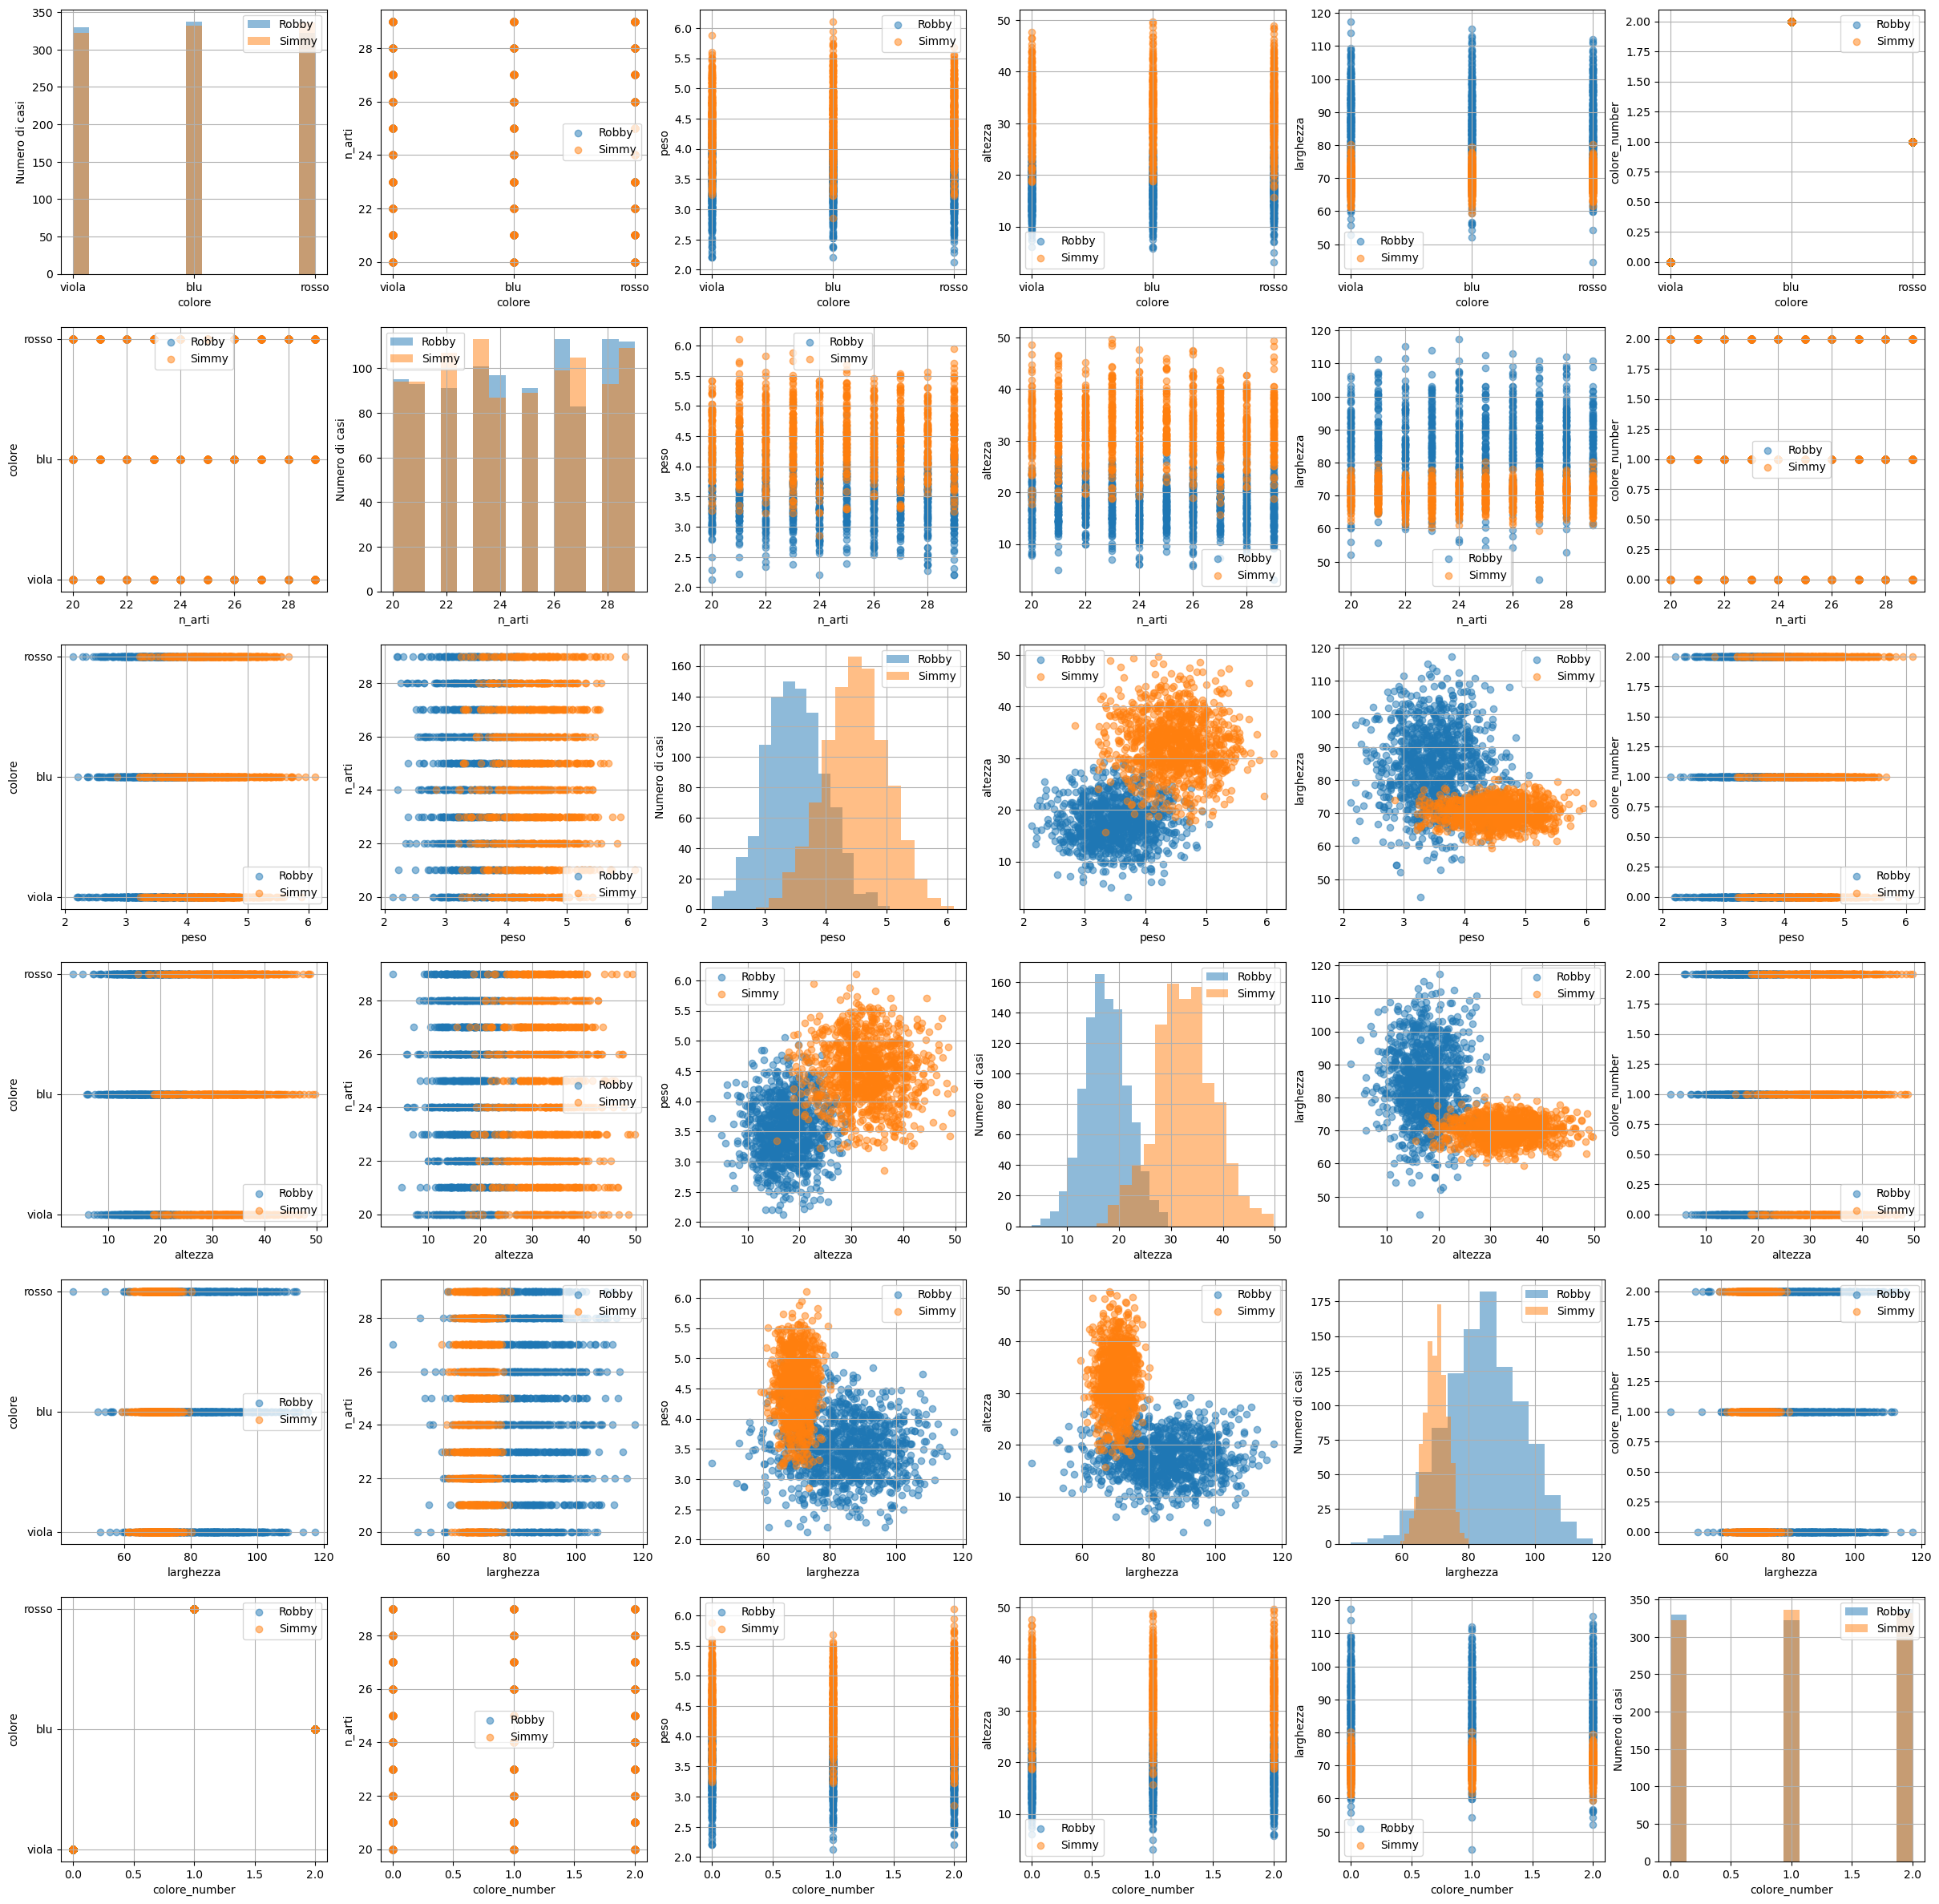

In [110]:
analisiGrafica(dati_puliti, 'specie')

## EX 11

In [113]:
data_laureati = pd.read_csv("./01_laureatixanno.csv", sep = ';')
data_laureati

,AnnoS,Lau_M,Lau_F,Lau,fonte dati
0,2024,175889.000,239664.000,415553.000,Anagrafe Nazionale degli Studenti universitari...
1,2023,167522.000,226338.000,393860.000,Anagrafe Nazionale degli Studenti universitari...
2,2022,157168.000,210583.000,367751.000,Anagrafe Nazionale degli Studenti universitari...
3,2021,160306.000,213668.000,373974.000,Anagrafe Nazionale degli Studenti universitari...
4,2020,153499.000,200518.000,354017.000,Anagrafe Nazionale degli Studenti universitari...
5,2019,149042.000,195079.000,344121.000,Anagrafe Nazionale degli Studenti universitari...
6,2018,141116.000,187155.000,328271.000,Anagrafe Nazionale degli Studenti universitari...
7,2017,134808.000,183670.000,318478.000,Anagrafe Nazionale degli Studenti universitari...
8,2016,131590.000,180575.000,312165.000,Anagrafe Nazionale degli Studenti universitari...
9,2015,127134.000,178078.000,305212.000,Anagrafe Nazionale degli Studenti universitari...


In [116]:
data_laureati2 = pd.read_csv("./02_laureatixateneo.csv", sep = ';', encoding='latin-1')
data_laureati2

,AnnoS,AteneoCOD,AteneoNOME,SESSO,Lau
0,2024,101,Torino,F,9533
1,2024,101,Torino,M,5326
2,2024,102,Torino Politecnico,F,2617
3,2024,102,Torino Politecnico,M,5341
4,2024,201,Piemonte Orientale,F,1442
...,...,...,...,...,...
4094,2001,8701,Catania,M,1663
4095,2001,9001,Sassari,F,922
4096,2001,9001,Sassari,M,508
4097,2001,9201,Cagliari,F,2023


In [121]:
data_laureati2.groupby('AteneoCOD')['Lau'].sum()

AteneoCOD
101     288786
102     137174
201      42260
401       1582
701       3719
         ...  
8301     99375
8601     16506
8701    152912
9001     47022
9201     97661
Name: Lau, Length: 92, dtype: int64